# 05. 閾値の正体は「sRNA の消費」— 04 を批判的に検算する

04 では化学量論 `m+s→∅` を *threshold*、触媒 `m+s→s` を *graded* と対比した。
でもあれは触媒側に**わざと弱い速度** $k_{cat}=0.1$ を与えた見かけだった疑いがある。
本当に「触媒＝なだらか」なのか? 両機構を **同じペアリング率** $k_{pair}$ の下で、
分岐確率 $\varphi$ で連続的につないで検算する。

$$ m + s \to \varnothing \;|\; k_{pair}(1-\varphi) \quad(\text{消費}) \qquad m + s \to s \;|\; k_{pair}\,\varphi \quad(\text{再利用}) $$

mRNA は $\varphi$ によらず常に $k_{pair}[m][s]$ で殺される。$\varphi$ は **sRNA が消費されるか**だけを変える。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

M, S = Species('m'), Species('s')
A_M, B_M, B_S, K_PAIR = 10.0, 1.0, 1.0, 5.0   # k_pair は中程度: 全 φ を1軸で見せるため

def build(a_s, phi):
    mdl = NetworkModel()
    rules = [ReactionRule([], [M], A_M), ReactionRule([], [S], a_s),
             ReactionRule([M], [], B_M), ReactionRule([S], [], B_S)]
    if (1-phi) > 0: rules.append(ReactionRule([M, S], [], K_PAIR*(1-phi)))  # 消費
    if phi > 0:     rules.append(ReactionRule([M, S], [S], K_PAIR*phi))     # 再利用
    for rr in rules: mdl.add_reaction_rule(rr)
    return mdl

def steady(a_s, phi):
    r = run_simulation(200.0, y0={'m':0,'s':0}, model=build(a_s, phi),
                       solver='ode', ndiv=2000, species_list=['m','s'])
    return r.as_array()[-1][1:3]   # m, s

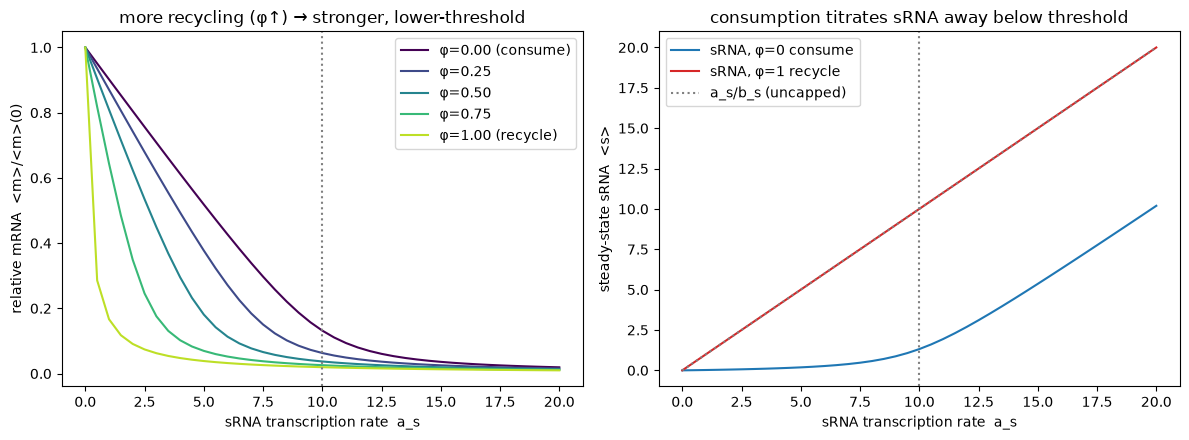

In [2]:
a_grid = np.linspace(0, 20, 41)
phis = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for phi, c in zip(phis, plt.cm.viridis(np.linspace(0, 0.9, len(phis)))):
    m = np.array([steady(a, phi)[0] for a in a_grid])
    tag = ' (consume)' if phi==0 else ' (recycle)' if phi==1 else ''
    ax1.plot(a_grid, m/A_M, '-', color=c, label=f'φ={phi:.2f}{tag}')
ax1.axvline(A_M, ls=':', c='gray')
ax1.set_xlabel('sRNA transcription rate  a_s'); ax1.set_ylabel('relative mRNA  <m>/<m>(0)')
ax1.set_title('more recycling (φ↑) → stronger, lower-threshold'); ax1.legend()

for phi, c in [(0.0, 'C0'), (1.0, 'C3')]:
    s = np.array([steady(a, phi)[1] for a in a_grid])
    ax2.plot(a_grid, s, '-', color=c, label=f'sRNA, φ={phi:.0f} ' + ('consume' if phi==0 else 'recycle'))
ax2.plot(a_grid, a_grid/B_S, ':', color='gray', label='a_s/b_s (uncapped)')
ax2.axvline(A_M, ls=':', c='gray')
ax2.set_xlabel('sRNA transcription rate  a_s'); ax2.set_ylabel('steady-state sRNA  <s>')
ax2.set_title('consumption titrates sRNA away below threshold'); ax2.legend()
plt.tight_layout(); plt.show()

## 読み取り — 04 の訂正

- **左**: $\varphi$ を上げて触媒寄りにするほど、silencing は**急峻に・低い $a_s$ で**効く。つまり同じペアリング率なら
  **触媒的 sRNA はむしろ強力なサイレンサー**であって「なだらか」ではない。04 の graded な曲線は
  触媒に弱い速度 $k_{cat}=0.1$ を与えた結果で、gradualness は *機構* ではなく *速度* の効果だった。
- **右**: なぜ消費だと閾値が立つか。$\varphi{=}0$（消費, 青）では sRNA が mRNA と対合して一緒に消えるため、
  $a_s < a_m$ の間は **free sRNA がほぼ 0 に滴定**される（青は $a_s/b_s$ 線より下、差が消費された分）。
  $a_s = a_m$ を超えて初めて sRNA が余り、mRNA を抑えきる。$\varphi{=}1$（再利用, 赤）では $s=a_s/b_s$ と
  **無制限に蓄積**（点線に一致）するので、少ない $a_s$ でも持続的に効く。

**結論**: 閾値スイッチ（$a_s{=}a_m$ 固定）を生むのは触媒/消費の別ではなく、**sRNA が消費（滴定）されること**。
しかも鋭い閾値には *消費* に加えて *強いペアリング* も要る（04 の $K_{STO}{=}100$ の極限）。

> **教訓（モデリング作法）**: 「機構 A は形 X」と結論する前に、比較している 2 モデルの
> **速度定数を揃えて**再検算する。パラメータの選び方が結論を作っていないか疑う。

## 発展課題（自作）

1. $k_{pair}$ を 5 → 100 に上げ、$\varphi{=}0$ で 04 のような鋭い linear-to-zero 閾値が戻るか確認。
2. 閾値の位置は $\varphi{=}0$ で本当に $a_s{=}a_m$ か。$a_m$ を変えて右パネルの「折れ点」が追随するか見る。
3. [[bio-a_hfq-phylogenetics]] の含意: オーソログ間で共分解の効率（consume 寄りか recycle 寄りか）が
   違うなら、同じ sRNA 量でも silencing の強さと閾値が変わる。$\varphi$ を系統の形質として解釈してみる。